In [8]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

In [9]:
import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet

In [32]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [11]:
# http://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
!wget -nc http://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2025-09-23 18:26:26--  http://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv [following]
--2025-09-23 18:26:27--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  --.-KB/s    in 0.08s   

2025-09-23 18:26:27 (61.9 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [12]:
df = pd.read_csv('bbc_text_cls.csv', engine='python')

In [13]:
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [14]:
inputs = df['text']
labels = df['labels']

<Axes: >

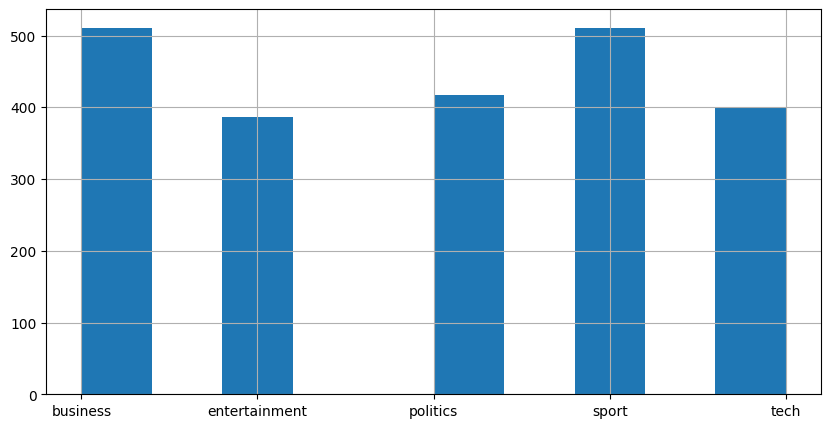

In [15]:
labels.hist(figsize=(10,5))

In [16]:
inputs_train, inputs_test, Y_train, Y_test = train_test_split(inputs, labels, random_state = 123)

In [17]:
vectorizer = CountVectorizer()

In [18]:
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

In [19]:
Xtrain

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 337411 stored elements and shape (1668, 26287)>

In [20]:
#The selected code (Xtrain != 0).sum() is calculating the number of
#non-zero elements in the Xtrain sparse matrix.
(Xtrain != 0).sum()

np.int64(337411)

Xtrain.shape: This returns a tuple representing the dimensions of the Xtrain matrix (number of rows, number of columns).
np.prod(Xtrain.shape): This calculates the total number of elements in the Xtrain matrix by multiplying the dimensions.

In [21]:
# what percentage of values are non_zero?
# prod : product
# Xtrain.shape()
(Xtrain !=0).sum() /np.prod(Xtrain.shape)

np.float64(0.007695239935415004)

In [22]:
model = MultinomialNB() # multinomial naive bayes
model.fit(Xtrain, Y_train)
print("train score:", model.score(Xtrain, Y_train))
print("test score:", model.score(Xtest, Y_test))


train score: 0.9922062350119905
test score: 0.9712746858168761


In [23]:
# with stopwords
vectorizer = CountVectorizer(stop_words= 'english')
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)
model = MultinomialNB()
model.fit(Xtrain,Y_train)
print("train score:", model.score(Xtrain,Y_train))
print("test score:", model.score(Xtest, Y_test))


train score: 0.9928057553956835
test score: 0.9766606822262118


In [24]:
def get_wordnet_pos(treebank_tag):
  if treebank_tag.startswith('J'):
    return wordnet.ADJ
  elif treebank_tag.startswith('V'):
    return wordnet.VERB
  elif treebank_tag.startswith('N'):
    return wordnet.NOUN
  elif treebank_tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN

In [30]:
class LemmaTokenizer:
  def __init__(self):
    self.wnl = WordNetLemmatizer()
    def __call__(self, doc):
      tokens = word_tokenize(doc)
      words_and_tags = nltk.pos_tag(tokens)
      return [self.wnl.lemmatize(word, pos = get_wordnet_pos(tag)) for word, tag in words_and_tags]

In [33]:
# with lemmatization

vectorizer = CountVectorizer(tokenizer= LemmaTokenizer())
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)
model = MultinomialNB()
model.fit(Xtrain,Y_train)
print("train score:", model.score(Xtrain,Y_train))
print("test score:", model.score(Xtest, Y_test))


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score: 0.9922062350119905
test score: 0.9676840215439856


In [36]:
class StemTokenizer:
  def __init__(self):
    self.porter = PorterStemmer()
  def __call__(self, doc):
    tokens = word_tokenize(doc)
    return [self.porter.stem(token) for token in tokens]


In [37]:
#with stemming
vectorizer = CountVectorizer(tokenizer= StemTokenizer())
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)
model = MultinomialNB()
model.fit(Xtrain,Y_train)
print("train score:", model.score(Xtrain,Y_train))
print("test score:", model.score(Xtest, Y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score: 0.9892086330935251
test score: 0.9694793536804309


In [38]:
def simple_tokenizer(s):
  return s.split()

In [41]:
#with split tokenizer
vectorizer = CountVectorizer(tokenizer= simple_tokenizer)
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)
model = MultinomialNB()
model.fit(Xtrain,Y_train)
print("train score:", model.score(Xtrain,Y_train))
print("test score:", model.score(Xtest, Y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score: 0.9952038369304557
test score: 0.9712746858168761
